# **week4/ day 1**

-	Random Forests: bagging intuition -> why averaging weak learners reduces variance
-	Train RandomForestClassifier on Titanic -> compare to decision tree baseline
-	Feature importances: plot them, drop bottom 20%, retrain ->did score improve?


## Random Forests: bagging intuition -> why averaging weak learners reduces variance

- Bagging (Bootstrap Aggregating):

  1. Take your 1000-row dataset. Sample 1000 rows with replacement — some rows appear twice, some not at all. That's a bootstrap sample.
  2. Train a tree on that sample. Repeat N times → N different trees.
  3. Aggregate: for classification, majority vote. For regression, average.
  - Result: variance drops because individual tree errors cancel out.

- The Random Forest extra trick:

  1.Bagged trees are still correlated (they all see the same strong features and split on them similarly).
  2. Fix: at each split, only consider a random subset of features (typically √p where p = total features).
  -This decorrelates the trees, making the averaging more effective.



- The key intuition:

 - High variance model + averaging many versions of it = lower variance, bias  roughly unchanged.

1. Task 1 -Baseline
- Train a DecisionTreeClassifier with no depth limit on  preprocessed Titanic data. Get a cross-validated accuracy score (5-fold). this is the score to be beaten.


In [67]:
import pandas as pd
import numpy as np


df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

df.fillna({'Age': df['Age'].median()}, inplace=True)
df.dropna(subset=['Embarked'], inplace=True)
df['Title'] = df['Name'].str.extract(r', ([A-Za-z]+)\.')
df['AgeGroup'] = df['Age'].apply(lambda x: 'Child' if x<13 else 'Teen' if x<18 else 'Adult' if x<61 else 'Senior')
df['Sex_encoded'] = df['Sex'].map({'male':0, 'female':1})

In [68]:
features = ['Pclass', 'Age', 'Fare', 'Sex_encoded']
X = df[features]
y = df['Survived']

In [69]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score


#decision tree
clf = DecisionTreeClassifier(random_state=42)

In [70]:
cross_valScore = cross_val_score(clf,X,y,cv=5)
print(cross_valScore)

[0.7247191  0.76404494 0.80898876 0.78651685 0.82485876]


In [71]:
print(np.mean(cross_valScore))

0.781825683996699


### 0.782 is  Decision Tree baseline.

2. Task 2 - Random Forest
Swap in RandomForestClassifier with default parameters. Same 5-fold CV. Record the score. The difference between Task 1 and Task 2 is bagging doing its job.

In [72]:
from sklearn.ensemble import RandomForestClassifier

#random forest
clfRf = RandomForestClassifier(random_state=42)

randomForest_crossVal_score = cross_val_score(clfRf,X,y,cv=5)
print(randomForest_crossVal_score)

[0.78651685 0.80898876 0.84831461 0.79775281 0.83050847]


In [73]:
print(np.mean(randomForest_crossVal_score))

0.8144163016568271


### 0.814 is Random Forest cross_val_score.

3. Task 3 -Tune slightly
 - adjusting n_estimators (starting at 100, try 200, 500).
 - Does the score keep improving or plateau? At what point does adding more trees stop helping?

In [74]:
estimators = [10, 50, 100, 200, 500]
N_estimator_cross_valScore=[]
estimator_mean = []
for i in estimators:
  Estimator_clf = RandomForestClassifier(n_estimators=i, random_state=42)
  N_estimator_cross_valScore = cross_val_score(Estimator_clf,X,y,cv=5)
  estimator_mean.append(np.mean(N_estimator_cross_valScore))
print(estimator_mean)

[np.float64(0.8200215831905033), np.float64(0.8121691106455913), np.float64(0.8144163016568271), np.float64(0.8132990541484162), np.float64(0.811058211134387)]


 n_estimators Tuning

- Scores across [10, 50, 100, 200, 500] trees ranged only from 0.811 to 0.820 -
  1. a difference of less than 1%. Beyond ~100 trees, additional estimators provide diminishing returns.
  
- The default n_estimators=100 is a reasonable choice  
  1. more trees increase computation time without meaningful accuracy gains.

 4. Task 4 - Feature Importances
- Plot feature_importances_ as a horizontal bar chart.
- Look at the ranking - does it match about what actually predicts survival?

In [75]:
clfRf.fit(X,y)

RandomForestClassifier(random_state=42)

In [76]:
forest_features = clfRf.feature_importances_

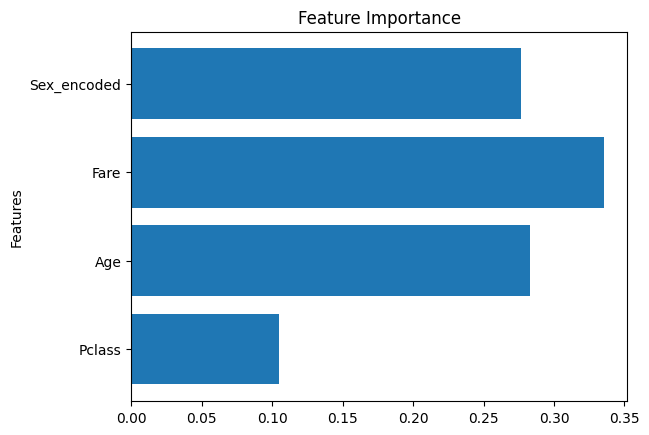

In [77]:
import matplotlib.pyplot as plt
fig,ax = plt.subplots()
ax.barh(features,forest_features)
ax.set_title("Feature Importance")
ax.set_ylabel("Features")
plt.show()

## Feature Importances

- Ranking: Fare > Age > Sex_encoded > Pclass

1. Fare ranks highest due to its continuous nature giving the forest more
split opportunities.
2. Sex_encoded ranks lower despite having the strongest
correlation (0.54) in EDA -> binary features have fewer possible splits.
3. Pclass ranks last because Fare captures similar information , causing the forest to assign Pclass less credit.

5. Task 5 - Drop bottom 20%
- Identify the lowest-importance features, drop them, retrain.
- Did the score go up, down, or stay flat? Why might dropping weak features help or hurt?

In [80]:
#dropping Pclass

NewFeatures= ['Age', 'Fare', 'Sex_encoded']
X_new = df[NewFeatures]

In [85]:
ran_forest = cross_val_score(clfRf,X_new,y,cv=5)

In [84]:
np.mean(ran_forest)

np.float64(0.7885545610359931)

## **0.814** is Random Forest cross_val_score with Pclass.
## **0.788** without Pclass

6. Task 6  
    1. what did bagging do to variance
    2. what did feature selection do to score

## Feature Selection Result

1. Dropping Pclass (lowest importance at ~0.10) reduced CV score from 0.814 to 0.789.

2. Bagging reduced variance by averaging 100 decorrelated trees: each trained on a bootstrap sample with random feature subsets -> producing a more stable model than a single decision tree (0.782 -> 0.814).

3. Feature selection hurt performance here because low importance ≠ zero importance.
4. Pclass still carried unique survival signal not fully captured by Fare, despite
their correlation. Bottom 20% removal is not always beneficial